The purpose of this experiment is to check whether the division length and rate are the same between simulated and theoretical samples.

### Setup

In [1]:
from scipy.stats import lognorm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

Fix a choice of parameters so that cell growth is not impeded by the environment (i.e., growth pressure is large).


In [2]:
gamma_values = np.array([1000,2000])
gamma_values

array([1000, 2000])

In [3]:
reg_param_values = np.array([3,3])
reg_param_values

array([3, 3])

Then assign a specific elongation rate and a specific division length (whatever you like). 




In [4]:
# division length
min_div_len = 2.0
division_shape = 0.42 ## sig
division_scale = 4.8 ## mu
division_local = -0.32 ## loc
division_mean = np.mean(np.maximum(min_div_len, lognorm.rvs(division_shape, loc=division_local, scale=division_scale, size=1000)))
division_mean

4.839674554548626

In [5]:
# elongation rate
growth_mu = 1.15
growth_mu

1.15

Here I'm specificially using the mean values as fixed. Note that they used to be randomly distributed.

Then do the math,

t=0: one cell of length L -> L=2.42=startVol

t=n: one cell of length 2L, divides -> 2L=4.84=targetVol

t=2n: two cells of length 2L, divide -> 2L=4.84=targetVol

….

T=mn: 2^(m-1) cells of length 2L -> 2L=4.84=targetVol

we know: m=8=# of generations

Note that here we assumed the length of initial mather cell is L, and the length of division is 2L. In other words, startVol*2=targetVol.

Then compare this theoretical with the simulated behaviour.

### 1st thing to check: division timepoints of 200 cells

In [6]:
path_1 = "C:/Users/MECHREV/Desktop/2026-05-01/iteration 000/gamma=1000.0_reg_param=3.0_iter=0/data/simulation_module_test-26-05-04-16-03/Trackrefiner.Objects_properties_Average_analysis.csv"

In [7]:
path_2 = "C:/Users/MECHREV/Desktop/2026-05-01/iteration 001/gamma=2000.0_reg_param=3.0_iter=1/data/simulation_module_test-26-05-04-16-04/Trackrefiner.Objects_properties_Average_analysis.csv"

We are taking this 2nd sample for this simple experiment, but feel free to switch it to the 1st one or any other sample path you have.

In [8]:
csv_path = path_2
df = pd.read_csv(csv_path)
df.head()

,ImageName,ImageNumber,ObjectNumber,AreaShape_Area,AreaShape_Center_X,AreaShape_Center_Y,AreaShape_MajorAxisLength,AreaShape_MinorAxisLength,AreaShape_Orientation,Location_Center_X,...,Elongation_Rate,Instant_Elongation_Rate,strainRate,strainRate_rolling,cellType,startVol,targetVol,Prev_Bacterium_Slope,Prev_MajorAxisLength,Bacterium_Movement
0,0,1,1,125.569369,18.65842,15.012435,2.474082,1.34,-0.0,18.65842,...,0.017,NaN,0.000000,0.000000,1,2.474082,4.88484,NaN,NaN,NaN
1,2,2,1,132.893390,18.65842,15.012435,2.618386,1.34,-0.0,18.65842,...,0.017,0.048,0.058327,0.029163,1,2.474082,4.88484,-0.0,2.474082,0.0
2,4,3,1,140.644603,18.65842,15.012435,2.771108,1.34,-0.0,18.65842,...,0.017,0.051,0.058327,0.038884,1,2.474082,4.88484,-0.0,2.618386,0.0
3,6,4,1,148.847908,18.65842,15.012435,2.932737,1.34,-0.0,18.65842,...,0.017,0.054,0.058326,0.043745,1,2.474082,4.88484,-0.0,2.771108,0.0
4,8,5,1,157.529699,18.65842,15.012435,3.103793,1.34,-0.0,18.65842,...,0.017,0.057,0.058327,0.046661,1,2.474082,4.88484,-0.0,2.932737,0.0


In [9]:
first_col = df.iloc[:, 0]
third_col = df.iloc[:, 2]
seen = set()
time_list = []

for row_idx, (col1, col3) in enumerate(zip(first_col, third_col)):
    if col3 not in seen:
        print(
            f"3rd-column value {col3} first appears at "
            f"row {row_idx}, associated 1st-column value = {col1}, "
            f"time = {round(col1*0.025,3)} h"
        )
        time_list.append(round(col1*0.025,3))
        seen.add(col3)

3rd-column value 1 first appears at row 0, associated 1st-column value = 0, time = 0.0 h
3rd-column value 2 first appears at row 14, associated 1st-column value = 26, time = 0.65 h
3rd-column value 3 first appears at row 49, associated 1st-column value = 60, time = 1.5 h
3rd-column value 4 first appears at row 53, associated 1st-column value = 62, time = 1.55 h
3rd-column value 5 first appears at row 118, associated 1st-column value = 94, time = 2.35 h
3rd-column value 6 first appears at row 124, associated 1st-column value = 96, time = 2.4 h
3rd-column value 7 first appears at row 125, associated 1st-column value = 96, time = 2.4 h
3rd-column value 8 first appears at row 140, associated 1st-column value = 100, time = 2.5 h
3rd-column value 9 first appears at row 253, associated 1st-column value = 128, time = 3.2 h
3rd-column value 10 first appears at row 263, associated 1st-column value = 130, time = 3.25 h
3rd-column value 11 first appears at row 264, associated 1st-column value = 13

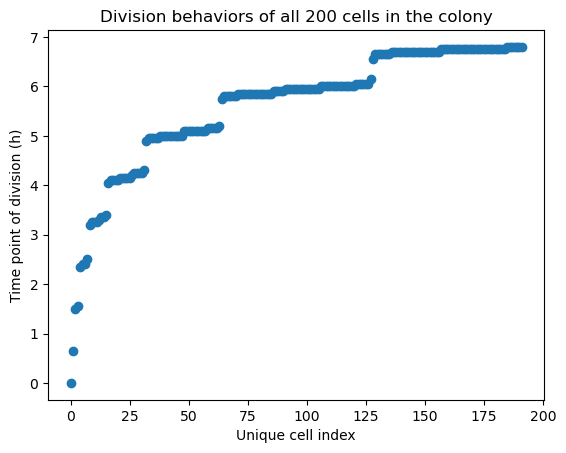

In [10]:
values = sorted(time_list)

x = range(len(values))

plt.plot(x, values, marker='o', linestyle='')

plt.xlabel("Unique cell index")
plt.ylabel("Time point of division (h)")
plt.title("Division behaviors of all 200 cells in the colony")

plt.show()

In [11]:
len(values)

192

This is the total number of cells in this colony, and this increasing trend is because we did sorting. We did the sorting because it is time series data, and the cell indices are increasing over time.

This timepoint result looks fine. It gives the trend: 0->n->2n->...->8n.

### 2nd thing to check: unique startVol and targetVol

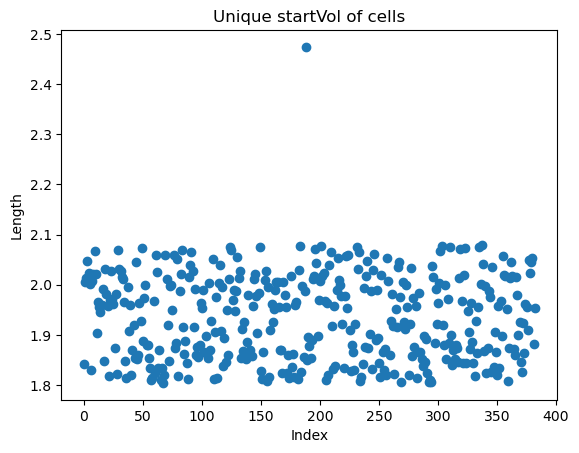

In [12]:
abc_set = set(df["startVol"])
values = list(abc_set)

x = range(len(values))

plt.plot(x, values, marker='o', linestyle='')

plt.xlabel("Index")
plt.ylabel("Length")
plt.title("Unique startVol of cells")

plt.show()

In [13]:
np.mean(values)  # recall that we set it 4.9/2 = 2.45 at the beginning of this notebook

1.9361319437702347

As we can see, the number of indices is 400 that is much more than 200 (i.e., the number of cells). This is simply because when the cells are divided, their children are given a new targetVol and startVol. That means even the id of the cell keeps the same (e.g., let's say id=1), they may have different targetVol and startVol. The cell where id=1 can be divided to 2 cells (i.e., id=1 and id=2), then the child where id=1 divides again and again. 

In [14]:
len(values)

383

As we can see, this total number of indices is different from 192.

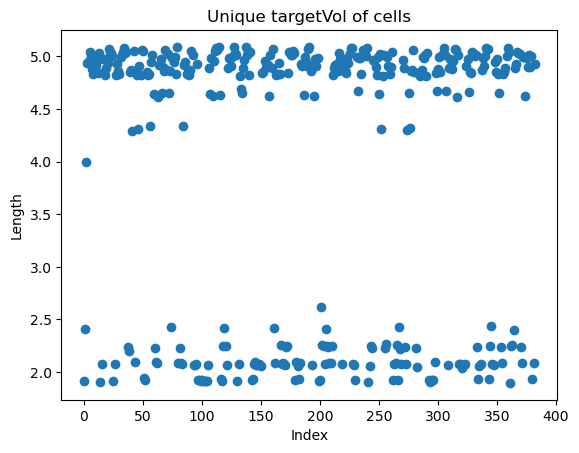

In [15]:
abc_set = set(df["targetVol"])
values = list(abc_set)

x = range(len(values))

plt.plot(x, values, marker='o', linestyle='')

plt.xlabel("Index")
plt.ylabel("Length")
plt.title("Unique targetVol of cells")

plt.show()

In [16]:
np.mean(values) # we set it 4.9

3.964869913253264

In [17]:
len(values)

383

Well, this is weird, it may have some stochasticity but shouldn't be such clearly to show 2 groups of lengths... So something went wrong here...

By the way, we fixed the targetVol and startVol as constant, but here they are still showing some stochasticity. We need to check this issue.

Another issue is, startVol*2 is very different from targetVol. The numbers of elements are the same (i.e., 383), but two plots don't match.

### 3rd thing to check: unique timepoint/startVol/targetVol/elongation_rate of one division branch

target the lineage of the initial cells w.r.t. only 1 track

get the first time the unique id appear

then get its associated parent id

Note that: (can be referred to https://github.com/Ati-74/Trackrefiner/wiki/Reported-Feature-Explanations)
 
1. "id" indicates the unique numerical identifier assigned to each bacterium for tracking throughout its lifecycle.
2. "parent_id" indicates the the ID of the mother bacterium. (Note: For bacteria existing in the first time step or with unexpected beginnings, this value is set to 0.)

In [18]:
## why the number of this id indices not equal to 200?

In [19]:
df["id"].count

<bound method Series.count of 0         1.0
1         1.0
2         1.0
3         1.0
4         1.0
        ...  
4741    761.0
4742    762.0
4743    763.0
4744    764.0
4745    765.0
Name: id, Length: 4746, dtype: float64>

In [20]:
df_first = df.drop_duplicates(subset="id", keep="first")
df_first

,ImageName,ImageNumber,ObjectNumber,AreaShape_Area,AreaShape_Center_X,AreaShape_Center_Y,AreaShape_MajorAxisLength,AreaShape_MinorAxisLength,AreaShape_Orientation,Location_Center_X,...,Elongation_Rate,Instant_Elongation_Rate,strainRate,strainRate_rolling,cellType,startVol,targetVol,Prev_Bacterium_Slope,Prev_MajorAxisLength,Bacterium_Movement
0,0,1,1,125.569369,18.658420,15.012435,2.474082,1.34,-0.000000,18.658420,...,0.017,NaN,0.0,0.0,1,2.474082,4.884840,NaN,NaN,NaN
13,26,14,1,100.853686,17.060845,15.012433,1.987111,1.34,-0.000066,17.060845,...,0.018,NaN,0.0,0.0,1,1.987111,4.920327,-0.000000,NaN,NaN
14,26,14,2,93.521176,20.255995,15.012435,1.842639,1.34,-0.000242,20.255995,...,0.018,NaN,0.0,0.0,1,1.842639,4.828957,-0.000000,NaN,NaN
48,60,31,2,101.832746,14.474310,15.047584,2.006401,1.34,-0.083549,14.474310,...,0.018,NaN,0.0,0.0,1,2.006401,4.968968,-0.060990,NaN,NaN
49,60,31,3,94.447059,17.659189,14.735097,1.860882,1.34,-0.133944,17.659189,...,0.018,NaN,0.0,0.0,1,1.860882,4.877540,-0.060990,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,272,137,188,97.854315,14.014473,11.534712,1.928014,1.34,-1.483505,14.014473,...,NaN,NaN,0.0,0.0,1,1.928014,1.928014,-6.817566,NaN,NaN
4742,272,137,189,104.525498,16.073693,14.037890,2.059456,1.34,-0.284725,16.073693,...,NaN,NaN,0.0,0.0,1,2.059456,2.059456,-0.325531,NaN,NaN
4743,272,137,190,96.941911,19.027246,13.121492,1.910037,1.34,-0.282169,19.027246,...,NaN,NaN,0.0,0.0,1,1.910037,1.910037,-0.325531,NaN,NaN
4744,272,137,191,104.990177,16.039479,13.379651,2.068612,1.34,-0.362913,16.039479,...,NaN,NaN,0.0,0.0,1,2.068612,2.068612,-0.320064,NaN,NaN


As we can see, this total of number of indices is the same as part2, not the part1, so "id" works in the same way as targetVol and startVol, which means the new born cell divided from its parent cells will be given a new "id". Keep this in mind here, because it is very different from the meaning of ObjectNumber.

ObjectNumber is the only unique reference of 200 cells in this colony.

In [21]:
current_parent = df.iloc[0]["parent_id"]   # starting parent id
kept_rows = []

for _, row in df.iterrows():
    row_id = row["id"]
    parent_id = row["parent_id"]

    if parent_id == current_parent:
        # keep the first child of this parent
        kept_rows.append(row)

        # now follow this child as the next parent
        current_parent = row_id

df_branch = pd.DataFrame(kept_rows)

df_branch["id"]

0         1.0
13      384.0
48      386.0
117     390.0
252     398.0
517     414.0
1039    446.0
2063    510.0
3945    638.0
Name: id, dtype: float64

In [22]:
df_branch["parent_id"]

0         0.0
13        1.0
48      384.0
117     386.0
252     390.0
517     398.0
1039    414.0
2063    446.0
3945    510.0
Name: parent_id, dtype: float64

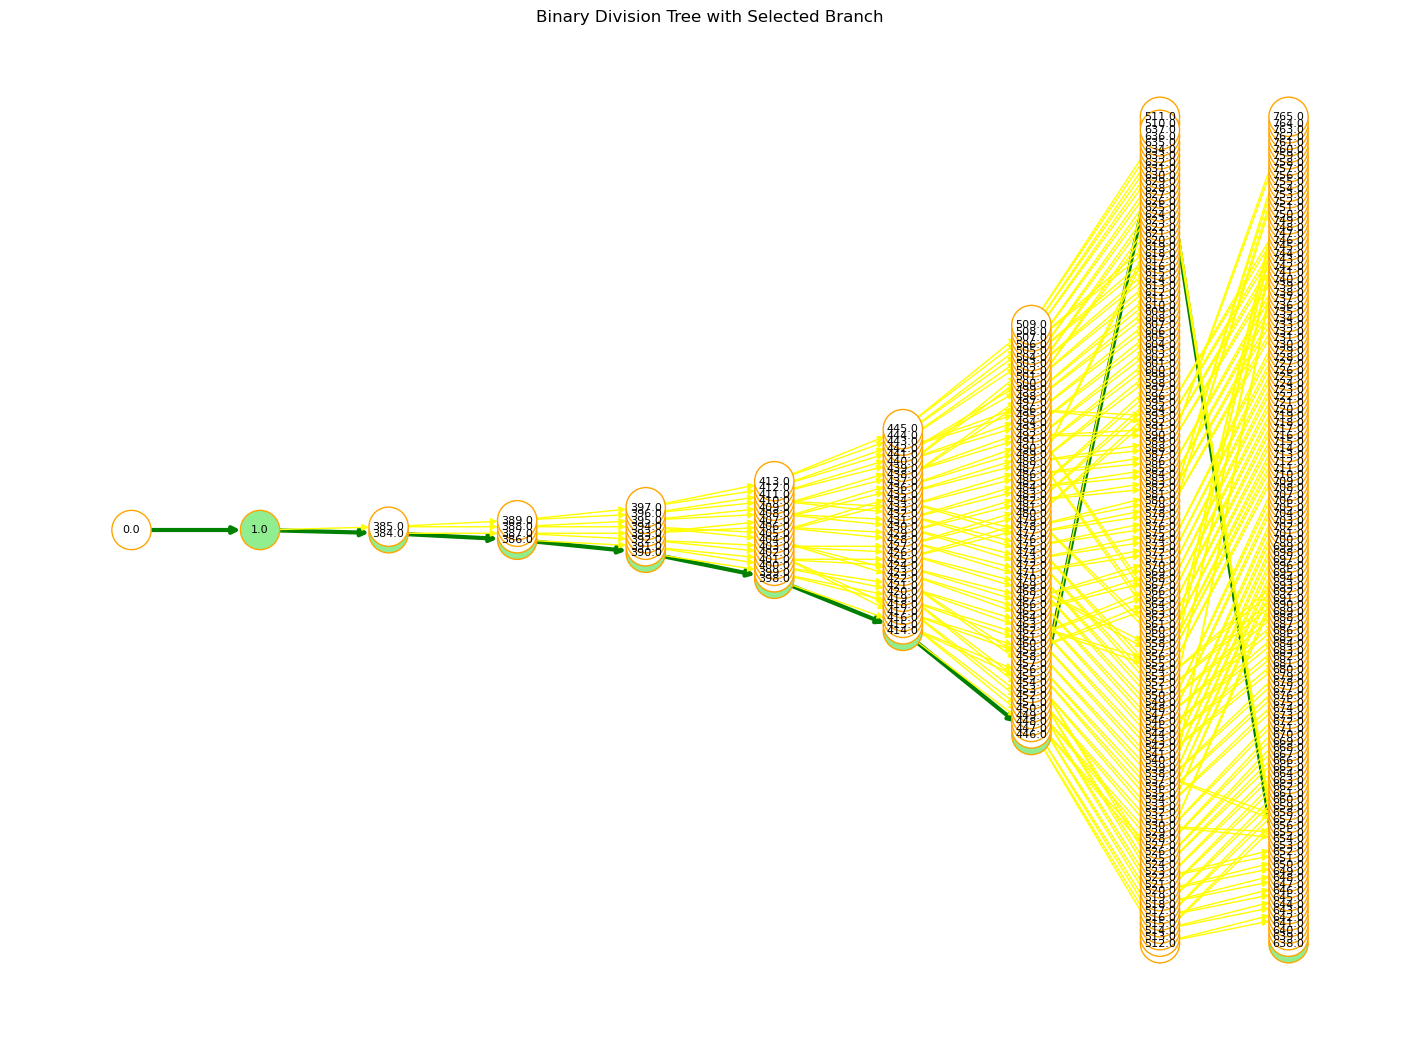

In [23]:
G = nx.DiGraph()

for _, row in df.iterrows():

    child = row["id"]
    parent = row["parent_id"]

    if pd.notna(parent):

        G.add_edge(parent, child)

current_parent = df.iloc[0]["parent_id"]

branch_nodes = []
branch_edges = []

visited = set()

while True:

    children = df[df["parent_id"] == current_parent]

    if len(children) == 0:
        break

    # first appeared child
    first_child = children.iloc[0]

    child_id = first_child["id"]

    branch_nodes.append(child_id)
    branch_edges.append((current_parent, child_id))

    if child_id in visited:
        break

    visited.add(child_id)

    current_parent = child_id

roots = [n for n, d in G.in_degree() if d == 0]

root = roots[0]

levels = {root: 0}

queue = [root]

while queue:

    node = queue.pop(0)

    for child in G.successors(node):

        levels[child] = levels[node] + 1
        queue.append(child)

# assign subset attribute
for node, level in levels.items():
    G.nodes[node]["subset"] = level

pos = nx.multipartite_layout(G, subset_key="subset")

node_colors = [
    "lightgreen" if node in branch_nodes else "white"
    for node in G.nodes()
]

edge_colors = [
    "green" if edge in branch_edges else "yellow"
    for edge in G.edges()
]

edge_widths = [
    3 if edge in branch_edges else 1
    for edge in G.edges()
]

plt.figure(figsize=(14, 10))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    edge_color=edge_colors,
    width=edge_widths,
    node_size=800,
    edgecolors="orange",
    arrows=True,
    font_size=8,
)

plt.title("Binary Division Tree with Selected Branch")

plt.axis("off")

plt.show()

In [24]:
values = df_branch["ImageName"]*0.025
values

0       0.00
13      0.65
48      1.50
117     2.35
252     3.20
517     4.05
1039    4.90
2063    5.75
3945    6.55
Name: ImageName, dtype: float64

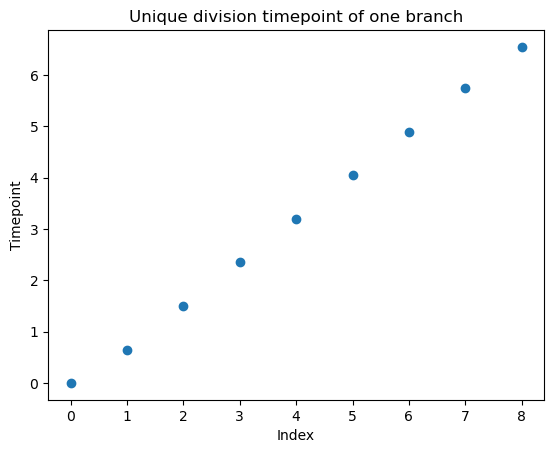

In [25]:
x = range(len(values))

plt.plot(x, values, marker='o', linestyle='')

plt.xlabel("Index")
plt.ylabel("Timepoint")
plt.title("Unique division timepoint of one branch")

plt.show()

In [26]:
values = df_branch["targetVol"]
values

0       4.884840
13      4.920327
48      4.968968
117     4.986590
252     5.010062
517     5.040863
1039    5.083252
2063    4.855500
3945    2.616231
Name: targetVol, dtype: float64

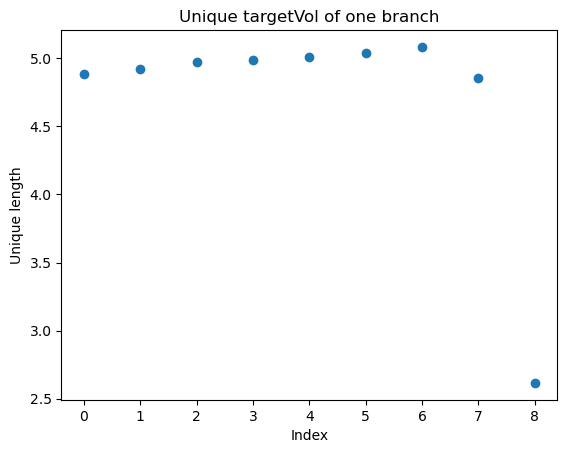

In [27]:
x = range(len(values))

plt.plot(x, values, marker='o', linestyle='')

plt.xlabel("Index")
plt.ylabel("Unique length")
plt.title("Unique targetVol of one branch")

plt.show()

In [28]:
np.mean(values)

4.707403551999999

In [29]:
values = df_branch["startVol"]
values

0       2.474082
13      1.987111
48      2.006401
117     2.013602
252     2.023187
517     2.035943
1039    2.052672
2063    2.075748
3945    1.971079
Name: startVol, dtype: float64

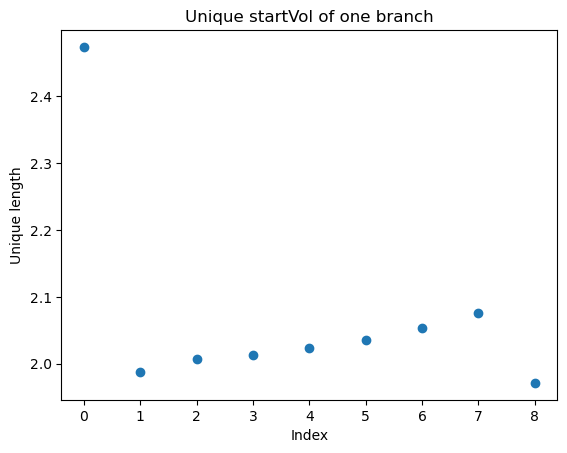

In [30]:
x = range(len(values))

plt.plot(x, values, marker='o', linestyle='')

plt.xlabel("Index")
plt.ylabel("Unique length")
plt.title("Unique startVol of one branch")

plt.show()

In [31]:
np.mean(values)

2.0710916399999997

In [32]:
values = df_branch["Elongation_Rate"]*60  # convert the unit
values

0       1.02
13      1.08
48      1.08
117     1.08
252     1.08
517     1.08
1039    1.08
2063    1.08
3945    0.96
Name: Elongation_Rate, dtype: float64

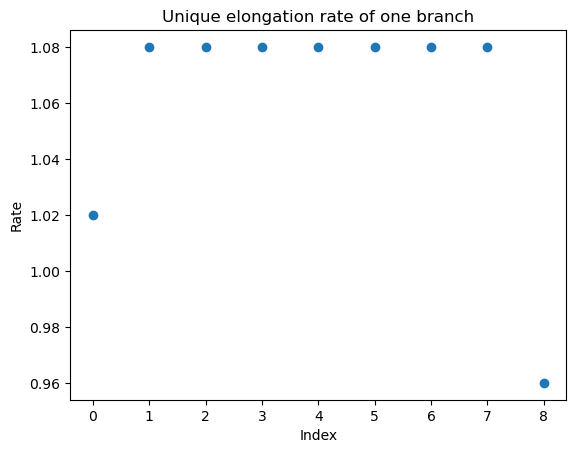

In [33]:
x = range(len(values))

plt.plot(x, values, marker='o', linestyle='')

plt.xlabel("Index")
plt.ylabel("Rate")
plt.title("Unique elongation rate of one branch")

plt.show()

In [34]:
np.mean(values)

1.0599999999999998

It is very clear now. There are 9 generations (clusters of divisions) in this colony. In each generation, the division timepoints are a little bit different because of the stochastisity, but they are very close.